# Training QSP Phase Angles via JAX Optimization

**A PennyLane community demo** | Ross Peili | Apache 2.0

---

Quantum Signal Processing (QSP) is a framework for encoding polynomial transformations of a
scalar signal into a quantum circuit. Given a target polynomial $P(x)$, the standard approach
computes the required phase angles analytically using classical solvers
(see [`qp.poly_to_angles`](https://docs.pennylane.ai/en/stable/code/api/pennylane.poly_to_angles.html)).

This demo takes the opposite route: **start from random phase angles and train them via
gradient descent** to recover a target polynomial. This is useful when:

- The polynomial is implicitly defined by a loss (not given in closed form)
- The circuit is embedded in a larger variational routine
- The analytic solver is numerically unstable at high degree

We implement the QSP circuit manually as a flat PennyLane sequence (no `qp.QSVT`),
use JAX for automatic differentiation, and Optax (Adam) as the optimizer.

**References**:
- Martyn et al., [A Grand Unification of Quantum Algorithms](https://arxiv.org/abs/2105.02859), PRX Quantum 2021
- Gilyen et al., [Quantum singular value transformation](https://arxiv.org/abs/1806.01838), STOC 2019

## 1. Background: The QSP Sequence

The standard 1-qubit QSP signal oracle $W(x)$ encodes a scalar $x \in (-1, 1)$
in its top-left matrix element:

$$
W(x) = H \, R_Z(-2\arccos x) \, H = \begin{pmatrix} x & i\sqrt{1-x^2} \\ i\sqrt{1-x^2} & x \end{pmatrix}
$$

A QSP sequence of degree $d$ with phase angles $(\phi_0, \phi_1, \ldots, \phi_d)$ is:

$$
U_{\text{QSP}}(x) = R_Z(-2\phi_0) \prod_{k=1}^{d} W(x) \, R_Z(-2\phi_k)
$$

The expectation value $\langle Z \rangle = \langle 0 | U_{\text{QSP}}^\dagger Z \, U_{\text{QSP}} | 0 \rangle$
encodes a degree-$d$ polynomial in $x$ determined by the phase angles.

**Key result** (Martyn et al. 2021): for any real bounded polynomial $P$ of degree $d$ with
appropriate parity, there exist phase angles $(\phi_0, \ldots, \phi_d)$ that realize $P$ exactly.

---

> **Note on circuit implementation**: `qp.QSVT` takes pre-built operator objects as arguments.
> Those objects capture concrete values at construction time, which breaks JAX tracing and
> produces zero gradients. We implement the QSP sequence manually as inline `qp.RZ` and
> `qp.Hadamard` gates, keeping the phase angles as live JAX tracers throughout.

## 2. Setup

In [1]:
import jax
import jax.numpy as jnp
import optax
import pennylane as qp
import matplotlib.pyplot as plt
import numpy as np

# float64 is enabled by qsp_jax.circuit at import time
from qsp_jax.circuit import qsp_circuit, target_poly, loss_fn

KEY = jax.random.PRNGKey(42)
print(f"JAX version   : {jax.__version__}")
print(f"PennyLane ver : {qp.__version__}")
print(f"JAX x64 active: {jax.config.jax_enable_x64}")

JAX version   : 0.9.0.1
PennyLane ver : 0.44.0
JAX x64 active: True


## 3. The Circuit

We build the QSP sequence manually: alternating the signal oracle
$W(x) = H \, R_Z(-2\arccos x) \, H$ with phase rotations $R_Z(-2\phi_k)$.

For a degree-$d$ polynomial, we use $d+1$ phase angles.

In [2]:
DEGREE = 5
N_PHASES = DEGREE + 1

dev = qp.device("default.qubit", wires=1)

@qp.qnode(dev, interface="jax")
def draw_circuit(phases, x):
    """Illustrative circuit for drawing only (same structure as qsp_jax.circuit)."""
    qp.RZ(-2.0 * phases[0], wires=0)
    for k in range(1, len(phases)):
        qp.Hadamard(wires=0)
        qp.RZ(-2.0 * jnp.arccos(x), wires=0)
        qp.Hadamard(wires=0)
        qp.RZ(-2.0 * phases[k], wires=0)
    return qp.expval(qp.PauliX(0))

example_phases = jnp.zeros(N_PHASES)
print(qp.draw(draw_circuit)(example_phases, 0.5))

0: ──RZ(-0.00)──H──RZ(-2.09)──H──RZ(-0.00)──H──RZ(-2.09)──H──RZ(-0.00)──H──RZ(-2.09)──H ···

0: ··· ──RZ(-0.00)──H──RZ(-2.09)──H──RZ(-0.00)──H──RZ(-2.09)──H──RZ(-0.00)─┤  <X>


## 4. Target Polynomial

The target is a degree-5 Chebyshev approximation of $\sin(x)$:

$$
P_{\text{target}}(x) = c_1 T_1(x) + c_3 T_3(x) + c_5 T_5(x)
$$

where $T_k$ are Chebyshev polynomials of the first kind. This is an odd polynomial,
bounded in $[-1, 1]$, consistent with degree-5 QSP conventions.

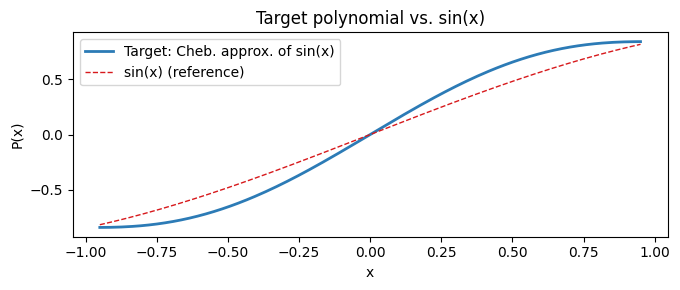

Max deviation from sin(x): 0.1738


In [3]:
xs = jnp.linspace(-0.95, 0.95, 200)

plt.figure(figsize=(7, 3))
plt.plot(xs, target_poly(xs), color="#2c7bb6", linewidth=2,
         label="Target: Cheb. approx. of sin(x)")
plt.plot(xs, jnp.sin(xs), color="#d7191c", linewidth=1, linestyle="--",
         label="sin(x) (reference)")
plt.xlabel("x")
plt.ylabel("P(x)")
plt.title("Target polynomial vs. sin(x)")
plt.legend()
plt.tight_layout()
plt.savefig("target_polynomial.png", dpi=120)
plt.show()

max_dev = float(jnp.max(jnp.abs(target_poly(xs) - jnp.sin(xs))))
print(f"Max deviation from sin(x): {max_dev:.4f}")

## 5. Training Loop

Minimize MSE between the QSP circuit output and the target polynomial over a uniform signal
grid. Optimizer: Adam (Optax). The phase angles are the only trainable parameters.
The entire computation graph — including the quantum circuit — is JAX-traced and JIT-compiled.

In [4]:
N_STEPS = 500
LEARNING_RATE = 0.05
N_SIGNAL_POINTS = 64

# Signal grid: stay strictly inside (-1, 1) for arccos validity
xs_train = jnp.linspace(-0.95, 0.95, N_SIGNAL_POINTS)

# Initialization: small random phases near zero
phases_init = jax.random.uniform(KEY, shape=(N_PHASES,), minval=-0.5, maxval=0.5)
print(f"Initial loss: {loss_fn(phases_init, xs_train):.6f}")

# Optimizer
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(phases_init)

@jax.jit
def step(phases, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(phases, xs_train)
    updates, opt_state_new = optimizer.update(grads, opt_state)
    phases_new = optax.apply_updates(phases, updates)
    return phases_new, opt_state_new, loss

# Training
phases = phases_init
loss_history = []

for i in range(N_STEPS):
    phases, opt_state, loss = step(phases, opt_state)
    loss_history.append(float(loss))
    if i % 100 == 0 or i == N_STEPS - 1:
        print(f"Step {i:4d} | loss = {float(loss):.6f}")

print(f"\nFinal phase angles: {np.round(np.array(phases), 4)}")

Initial loss: 1.440118


Step    0 | loss = 1.440118
Step  100 | loss = 0.000659
Step  200 | loss = 0.000652
Step  300 | loss = 0.000648
Step  400 | loss = 0.000643
Step  499 | loss = 0.000637

Final phase angles: [-0.0733 -0.2631 -0.9651  1.4105  0.8982 -0.1731]


## 6. Results

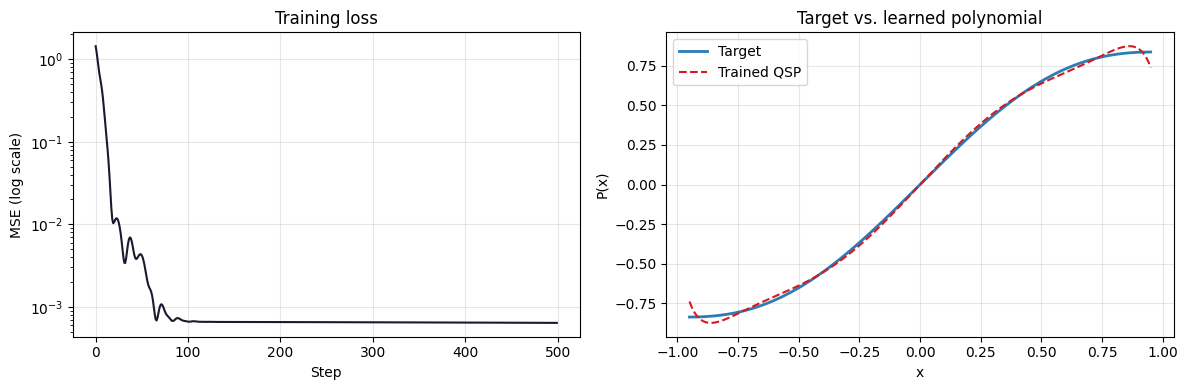

Final MSE    : 4.82e-04
Max |error|  : 9.83e-02


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.semilogy(loss_history, color="#1a1a2e", linewidth=1.5)
ax1.set_xlabel("Step")
ax1.set_ylabel("MSE (log scale)")
ax1.set_title("Training loss")
ax1.grid(True, alpha=0.3)

# Polynomial fit
xs_eval = jnp.linspace(-0.95, 0.95, 200)
circuit_vals = jax.vmap(lambda x: qsp_circuit(phases, x))(xs_eval)

ax2.plot(xs_eval, target_poly(xs_eval), color="#2c7bb6", linewidth=2, label="Target")
ax2.plot(xs_eval, circuit_vals, color="#d7191c", linewidth=1.5,
         linestyle="--", label="Trained QSP")
ax2.set_xlabel("x")
ax2.set_ylabel("P(x)")
ax2.set_title("Target vs. learned polynomial")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_results.png", dpi=120)
plt.show()

final_mse = float(loss_fn(phases, xs_eval))
max_err = float(jnp.max(jnp.abs(circuit_vals - target_poly(xs_eval))))
print(f"Final MSE    : {final_mse:.2e}")
print(f"Max |error|  : {max_err:.2e}")

## 7. Analysis

### Implementation note

The circuit uses the standard QSP signal oracle $W(x) = H R_Z(-2\arccos x) H$.
This is distinct from a naive `RZ(-2x)` signal — a flat sequence of `RZ` gates
on a single qubit all commute, collapsing to a single rotation with zero gradient
w.r.t. the phase angles. The Hadamard sandwich creates the entanglement between
the signal and the phase rotations that makes polynomial encoding non-trivial.

### Trainability

**Degree vs. trainability**: Degree 5 is tractable with Adam. Higher degrees produce
a more complex loss landscape and may require better initialization or second-order methods.

**Local minima**: QSP polynomial encoding is non-convex. The analytic solution
(via `qp.poly_to_angles`) is one valid point; gradient descent converges to
a symmetry-related equivalent.

**When to train vs. solve analytically**:

| Scenario | Approach |
|---|---|
| Known target polynomial, degree < 1000 | `qp.poly_to_angles` (exact) |
| Implicit loss or end-to-end variational circuit | Gradient training (this demo) |
| Degree > 1000 | `poly_to_angles` with `iterative` solver |

## 8. Conclusion

This demo showed how to train QSP phase angles from scratch via JAX gradient descent:

1. Implement the QSP sequence as a flat PennyLane circuit (inline `qp.RZ` + `qp.Hadamard`)
2. Define an MSE loss over a signal grid
3. Differentiate through the full circuit with `jax.grad` + `jax.vmap`
4. Optimize with Adam (Optax)

**Extensions**:
- Replace the target polynomial with an implicit loss (e.g., quantum simulation energy)
- Scale to multi-qubit block encodings with `qp.BlockEncode` or `qp.FABLE`
- Embed this circuit as a subroutine in a larger VQA and train end-to-end

---

*License: Apache 2.0 — [github.com/rosspeili/qsp-pennylane-demo](https://github.com/rosspeili/qsp-pennylane-demo)*